# Wine Quality Classification - LLM Comparison

Compare three local LLMs (via Ollama) on a 3-class wine quality classification task,
across multiple prompting strategies. The goal is to study how prompt engineering
(few-shot, chain-of-thought, retrieval-augmented exemplars, self-consistency)
affects classification accuracy of off-the-shelf instruction-tuned LLMs.

**Models:**
- Llama 3.1 8B (Meta)
- Qwen 2.5 7B (Alibaba)
- Mistral 7B v0.3 (Mistral AI)

**Prompting strategies:**
- Zero-shot Chain-of-Thought (CoT)
- Few-shot CoT with K=3 random exemplars per class
- Retrieval-Augmented Few-shot CoT (kNN K=5 via SBERT)
- Self-consistency (majority vote of N=3 sampled CoT runs) on the winning model


## 0. Install dependencies

In [1]:
%pip install -q datasets ollama sentence-transformers pandas numpy matplotlib seaborn scipy scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


## Pull LLMs via Ollama (one-time)

Run these in PowerShell with `ollama serve` already started in another terminal:

```powershell
ollama pull llama3.1:8b
ollama pull qwen2.5:7b
ollama pull mistral:7b
```

Approximate disk usage: ~13 GB total (each ~4-5 GB at Q4_K_M quantization).
Each model fits comfortably in 8 GB VRAM at this quantization.


## 1. Imports & Configuration

In [ ]:
import os, json, time, re, gc, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    matthews_corrcoef, confusion_matrix,
)
warnings.filterwarnings("ignore")

import ollama

RANDOM_SEED       = 42
N_TEST_EVAL       = 300         
N_RETRIEVAL_POOL  = 5000      
FEWSHOT_K_RANDOM  = 3             
RETRIEVAL_K       = 5          
SC_NUM_SAMPLES    = 3            
SC_TEMPERATURE    = 0.6
NUM_CLASSES       = 3
CLASS_NAMES       = ["Low", "Medium", "High"]

LLM_MODELS = [
    ("llama3.1:8b",  "Llama-3.1-8B"),
    ("qwen2.5:7b",   "Qwen-2.5-7B"),
    ("mistral:7b",   "Mistral-7B-v0.3"),
]

OLLAMA_OPTIONS_DETERMINISTIC = {
    "temperature": 0.0,
    "num_predict": 200,
    "top_p":       1.0,
}

OLLAMA_OPTIONS_SAMPLED = {
    "temperature": SC_TEMPERATURE,
    "num_predict": 200,
    "top_p":       0.95,
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Ollama version:", ollama.__version__ if hasattr(ollama, "__version__") else "unknown")
print(f"Eval test size : {N_TEST_EVAL}")
print(f"Retrieval pool : {N_RETRIEVAL_POOL}")
print(f"Models         : {[name for _, name in LLM_MODELS]}")


Ollama version: unknown
Eval test size : 300
Retrieval pool : 5000
Models         : ['Llama-3.1-8B', 'Qwen-2.5-7B', 'Mistral-7B-v0.3']


## 2. Data Loading

`james-burton/wine_reviews_ordinal` (Burton 2023) - WineMag corpus reformulated for ordinal
classification, with predefined train / val / test splits.


In [ ]:
from datasets import load_dataset

ds = load_dataset("james-burton/wine_reviews_ordinal")
train_raw = ds["train"].to_pandas()
test_raw  = ds["test"].to_pandas()

print(f"Train: {len(train_raw):,} | Test: {len(test_raw):,}")

def normalise(df):
    df = df.rename(columns={
        "description": "review",
        "points":      "rating",
        "province":    "region",
        "variety":     "grape",
    }).copy()
    df = df.dropna(subset=["rating", "review"]).reset_index(drop=True)
    df = df[df["review"].astype(str).str.strip().str.len() > 10].reset_index(drop=True)
    df["price"]   = pd.to_numeric(df["price"], errors="coerce")
    df["price"]   = df["price"].fillna(df["price"].median())
    df["country"] = df["country"].fillna("Unknown").astype(str)
    df["region"]  = df["region"].fillna("Unknown").astype(str)
    df["grape"]   = df["grape"].fillna(-1).astype(int).astype(str)
    return df

train_df = normalise(train_raw)
test_df  = normalise(test_raw)
print(f"After cleaning - Train: {len(train_df):,} | Test: {len(test_df):,}")
train_df.head(2)


Train: 71,504 | Test: 21,031
After cleaning - Train: 71,504 | Test: 21,031


,country,review,rating,price,region,grape
0,France,"Although it's not indicated on the label, this...",92,27.0,Champagne,5
1,US,"A touch salty on the entry, this wine offers s...",84,17.0,California,5


## 3. Tertile Binning

Quality scores (80-100) are partitioned into 3 ordinal classes (Low / Medium / High)
using percentile cut-offs from the training distribution.


In [ ]:
train_df["label"], bins = pd.qcut(
    train_df["rating"], q=NUM_CLASSES,
    labels=False, retbins=True, duplicates="drop"
)
train_df = train_df.dropna(subset=["label"]).reset_index(drop=True)
train_df["label"] = train_df["label"].astype(int)

def bin_with_edges(rating):
    for k in range(NUM_CLASSES):
        if rating <= bins[k+1]:
            return k
    return NUM_CLASSES - 1

test_df["label"] = test_df["rating"].apply(bin_with_edges).astype(int)

print(f"Bin edges: {np.round(bins, 2)}")
print(f"Train class distribution: {train_df['label'].value_counts(normalize=True).sort_index().round(3).to_dict()}")
print(f"Test class distribution : {test_df['label'].value_counts(normalize=True).sort_index().round(3).to_dict()}")

print("\nTertile bin descriptions:")
for k in range(NUM_CLASSES):
    lo, hi = float(bins[k]), float(bins[k+1])
    print(f"  Class {k} ({CLASS_NAMES[k]:<6s}): rating in ({lo:.1f}, {hi:.1f}]")


Bin edges: [ 80.  87.  90. 100.]
Train class distribution: {0: 0.386, 1: 0.34, 2: 0.274}
Test class distribution : {0: 0.386, 1: 0.339, 2: 0.275}

Tertile bin descriptions:
  Class 0 (Low   ): rating in (80.0, 87.0]
  Class 1 (Medium): rating in (87.0, 90.0]
  Class 2 (High  ): rating in (90.0, 100.0]


## 4. Sample Test Subset + Retrieval Pool

A deterministic, class-stratified subset of 300 test reviews keeps total runtime
manageable (3 LLMs × 3 strategies × 300 calls).

A class-stratified subsample of 5000 training reviews serves as the retrieval pool
for the kNN exemplar-selection strategy.


In [5]:
def stratified_subsample(df, n, seed=RANDOM_SEED):
    n_per = n // df["label"].nunique()
    parts = []
    for k, g in df.groupby("label"):
        parts.append(g.sample(n=min(n_per, len(g)), random_state=seed))
    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1, random_state=seed).reset_index(drop=True)

test_eval_df = stratified_subsample(test_df, N_TEST_EVAL)
retrieval_pool = stratified_subsample(train_df, N_RETRIEVAL_POOL)

print(f"Test eval subset: {len(test_eval_df)}  | classes: {test_eval_df['label'].value_counts().sort_index().to_dict()}")
print(f"Retrieval pool  : {len(retrieval_pool)} | classes: {retrieval_pool['label'].value_counts().sort_index().to_dict()}")


Test eval subset: 300  | classes: {0: 100, 1: 100, 2: 100}
Retrieval pool  : 4998 | classes: {0: 1666, 1: 1666, 2: 1666}


## 5. SBERT Embeddings (for retrieval-augmented few-shot)

Encode the retrieval pool and test subset with `all-mpnet-base-v2`. L2-normalized
embeddings allow cosine similarity to be computed as a simple dot product.


In [ ]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
sbert = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=device)
print(f"SBERT loaded on {device}, dim = {sbert.get_sentence_embedding_dimension()}")

print("Encoding retrieval pool...")
pool_emb = sbert.encode(retrieval_pool["review"].tolist(), batch_size=128,
                          show_progress_bar=True, convert_to_numpy=True,
                          normalize_embeddings=True)

print("Encoding test subset...")
test_emb = sbert.encode(test_eval_df["review"].tolist(), batch_size=128,
                          show_progress_bar=True, convert_to_numpy=True,
                          normalize_embeddings=True)

del sbert
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Pool embeddings: {pool_emb.shape}  | Test embeddings: {test_emb.shape}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

SBERT loaded on cuda, dim = 768
Encoding retrieval pool...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Encoding test subset...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Pool embeddings: (4998, 768)  | Test embeddings: (300, 768)


## 6. Prompt Templates

A unified system prompt for all strategies, plus three exemplar-selection schemes:
zero-shot, random few-shot, retrieval-augmented few-shot.

The model is instructed to respond in strict JSON
(`{"reasoning": "...", "label": 0|1|2}`) so that we can parse the answer reliably
even when the model adds prose around it.


In [ ]:
def class_description():
    rng = []
    for k in range(NUM_CLASSES):
        lo, hi = float(bins[k]), float(bins[k+1])
        rng.append(f"  - Class {k} = {CLASS_NAMES[k]} (WineMag points in [{lo:.0f}, {hi:.0f}])")
    return "\n".join(rng)

CLASS_RANGES = class_description()

SYSTEM_PROMPT = (
    "You are a professional sommelier and wine quality expert.\n"
    "Your task: classify a wine into one of three ordinal quality classes\n"
    "based on its tabular metadata and a tasting-note review.\n\n"
    "Quality classes (tertile bins of WineMag's 80-100 score):\n"
    f"{CLASS_RANGES}\n\n"
    "Reasoning checklist (perform mentally before answering):\n"
    "  1. Origin prestige: country, region, grape variety reputation.\n"
    "  2. Price tier (USD): typical for everyday, mid, or premium wine.\n"
    "  3. Review descriptors: complexity, balance, finish length, structure.\n"
    "     - HIGH cues: 'concentrated', 'elegant', 'layered', 'refined', 'lingering finish'.\n"
    "     - LOW cues : 'simple', 'thin', 'flat', 'short', 'lacks complexity'.\n\n"
    'Respond ONLY with valid JSON of the form:\n'
    '{"reasoning": "<one short sentence>", "label": <0|1|2>}'
)


def format_wine(row):
    return (f"Country: {row['country']} | Region: {row['region']} | "
             f"Grape: {row['grape']} | Price: {row['price']:.0f} USD\n"
             f"Review: {str(row['review'])[:380]}")


def format_exemplar(row, with_reasoning=True):
    txt = format_wine(row)
    if with_reasoning:
        cues = {0: "Lacks key high-end markers; entry-level price/origin.",
                 1: "Solid, balanced, mid-tier without elite signals.",
                 2: "Strong premium descriptors and origin prestige."}
        return (f"{txt}\n"
                 f'{{"reasoning": "{cues[int(row["label"])]}", "label": {int(row["label"])}}}')
    return f"{txt}\nLabel: {int(row['label'])}"


def build_prompt_zeroshot(test_row):
    user = (
        "Now classify this new wine. Reply with ONLY the JSON answer.\n\n"
        f"{format_wine(test_row)}"
    )
    return SYSTEM_PROMPT, user


def build_prompt_fewshot_random(test_row, rng):
    examples_per_class = []
    for k in range(NUM_CLASSES):
        pool = retrieval_pool[retrieval_pool["label"] == k]
        idx  = rng.choice(len(pool), size=FEWSHOT_K_RANDOM, replace=False)
        for i in idx:
            examples_per_class.append(format_exemplar(pool.iloc[i]))
    rng.shuffle(examples_per_class)
    body = "\n\n".join(["EXAMPLES:"] + examples_per_class)
    user = (
        f"{body}\n\n"
        "Now classify this new wine. Reply with ONLY the JSON answer.\n\n"
        f"{format_wine(test_row)}"
    )
    return SYSTEM_PROMPT, user


def build_prompt_retrieval(test_row, test_idx):
    sims  = pool_emb @ test_emb[test_idx]    
    top   = np.argsort(-sims)[:RETRIEVAL_K]
    examples = [format_exemplar(retrieval_pool.iloc[i]) for i in top]
    body = "\n\n".join(["NEAREST-NEIGHBOR EXAMPLES (most similar reviews):"] + examples)
    user = (
        f"{body}\n\n"
        "Using the patterns visible in the examples above, classify this new wine. "
        "Reply with ONLY the JSON answer.\n\n"
        f"{format_wine(test_row)}"
    )
    return SYSTEM_PROMPT, user


## 7. LLM Runner + Robust Output Parsing

Sends a chat request to Ollama and extracts the predicted label from the response.
Parsing prefers a JSON match; falls back to the last integer in {0, 1, 2} found
in the text. Returns `None` only on a true parse failure (counted as a separate stat).


In [ ]:
JSON_RE  = re.compile(r'\{[^{}]*"label"\s*:\s*([0-2])[^{}]*\}', re.DOTALL)
LABEL_RE = re.compile(r'\b(?:label|class|prediction)\s*[:=]?\s*([0-2])\b', re.IGNORECASE)


def parse_label(text):
    if not text:
        return None
    m = JSON_RE.search(text)
    if m:
        return int(m.group(1))
    m = LABEL_RE.search(text)
    if m:
        return int(m.group(1))
    digits = [int(c) for c in text if c in "012"]
    if digits:
        return digits[-1]
    return None


def call_llm(model, system, user, options=None):
    if options is None:
        options = OLLAMA_OPTIONS_DETERMINISTIC
    try:
        resp = ollama.chat(
            model=model,
            messages=[{"role": "system", "content": system},
                       {"role": "user",   "content": user}],
            options=options,
        )
        return resp["message"]["content"]
    except Exception as e:
        return f"<<ERR: {e}>>"


def evaluate_strategy(model_name, model_id, strategy, test_subset,
                       options=None):
    """Run a (model, strategy) combo over the test subset."""
    rng_local = np.random.RandomState(RANDOM_SEED)
    preds, true, raw_outputs, parse_failures = [], [], [], 0
    t0 = time.time()
    desc = f"{model_name:>16s} | {strategy:<14s}"
    for i, (_, row) in enumerate(tqdm(test_subset.iterrows(),
                                       total=len(test_subset), desc=desc)):
        if strategy == "zero_shot":
            sys_p, user_p = build_prompt_zeroshot(row)
        elif strategy == "fewshot_random":
            sys_p, user_p = build_prompt_fewshot_random(row, rng_local)
        elif strategy == "retrieval":
            sys_p, user_p = build_prompt_retrieval(row, i)
        else:
            raise ValueError(strategy)
        out = call_llm(model_id, sys_p, user_p, options=options)
        raw_outputs.append(out)
        pred = parse_label(out)
        if pred is None:
            parse_failures += 1
            pred = NUM_CLASSES // 2       
        preds.append(pred)
        true.append(int(row["label"]))
    elapsed = time.time() - t0
    return {
        "model":          model_name,
        "model_id":       model_id,
        "strategy":       strategy,
        "preds":          np.array(preds),
        "labels":         np.array(true),
        "raw":            raw_outputs,
        "parse_failures": parse_failures,
        "elapsed_s":      elapsed,
    }


## 7b. Quick Sanity Check

Issue one prompt to each model to confirm Ollama is reachable and the model is
loaded into VRAM. If a model fails here, pull it via `ollama pull <name>`.


In [12]:
for model_id, model_name in LLM_MODELS:
    try:
        sys_p, user_p = build_prompt_zeroshot(test_eval_df.iloc[0])
        t0  = time.time()
        out = call_llm(model_id, sys_p, user_p)
        dt  = time.time() - t0
        pred = parse_label(out)
        true = int(test_eval_df.iloc[0]["label"])
        print(f"[OK] {model_name:<18s} latency={dt:.1f}s  pred={pred}  true={true}")
        print(f"     raw: {out[:200]!r}")
    except Exception as e:
        print(f"[ERR] {model_name}: {e}")


[OK] Llama-3.1-8B       latency=10.8s  pred=2  true=2
     raw: '{"reasoning": "The wine\'s oxidative style and Jura origin suggest a complex and refined taste experience.", "label": 2}'
[OK] Qwen-2.5-7B        latency=21.3s  pred=2  true=2
     raw: '{"reasoning": "The oxidative style, unique flavors, and versatility as both a food and apéritif suggest a high-quality wine.", "label": 2}'
[OK] Mistral-7B-v0.3    latency=8.0s  pred=1  true=2
     raw: ' {"reasoning": "Price suggests medium quality, but oxidative style and descriptors indicate complexity.", "label": 1}'


## 8. Main Sweep: 3 Models × 3 Strategies

In [13]:
STRATEGIES = ["zero_shot", "fewshot_random", "retrieval"]
all_runs = []

for model_id, model_name in LLM_MODELS:
    for strategy in STRATEGIES:
        run = evaluate_strategy(model_name, model_id, strategy, test_eval_df)
        acc = accuracy_score(run["labels"], run["preds"])
        print(f"--> {model_name:<18s} {strategy:<14s}  acc={acc:.4f}  "
               f"parse_fails={run['parse_failures']:3d}/{len(test_eval_df)}  "
               f"time={run['elapsed_s']/60:.1f}min")
        all_runs.append(run)


    Llama-3.1-8B | zero_shot     :   0%|          | 0/300 [00:00<?, ?it/s]

--> Llama-3.1-8B       zero_shot       acc=0.6067  parse_fails=  0/300  time=22.5min


    Llama-3.1-8B | fewshot_random:   0%|          | 0/300 [00:00<?, ?it/s]

--> Llama-3.1-8B       fewshot_random  acc=0.6300  parse_fails=  0/300  time=19.9min


    Llama-3.1-8B | retrieval     :   0%|          | 0/300 [00:00<?, ?it/s]

...

--> Mistral-7B-v0.3    zero_shot       acc=0.6400  parse_fails=  0/300  time=18.7min


 Mistral-7B-v0.3 | fewshot_random:   0%|          | 0/300 [00:00<?, ?it/s]

--> Mistral-7B-v0.3    fewshot_random  acc=0.5733  parse_fails=  0/300  time=20.1min


 Mistral-7B-v0.3 | retrieval     :   0%|          | 0/300 [00:00<?, ?it/s]

--> Mistral-7B-v0.3    retrieval       acc=0.6233  parse_fails=  0/300  time=17.4min


## 9. Self-Consistency Bonus on the Best (Model, Strategy)

For the highest-scoring (model, strategy) pair, draw N=3 sampled completions per
test instance (temperature 0.6) and take the majority vote. This typically lifts
accuracy by 1-3 points by averaging out single-shot stochasticity.


In [14]:
best_run = max(all_runs, key=lambda r: accuracy_score(r["labels"], r["preds"]))
print(f"Best so far: {best_run['model']} + {best_run['strategy']} -> "
       f"acc {accuracy_score(best_run['labels'], best_run['preds']):.4f}")

print(f"\nRunning self-consistency (N={SC_NUM_SAMPLES} samples per item)...")
rng_sc = np.random.RandomState(RANDOM_SEED)
sc_preds, sc_true, sc_failures = [], [], 0
t0 = time.time()
for i, (_, row) in enumerate(tqdm(test_eval_df.iterrows(),
                                    total=len(test_eval_df), desc="self-consistency")):
    if best_run["strategy"] == "zero_shot":
        sys_p, user_p = build_prompt_zeroshot(row)
    elif best_run["strategy"] == "fewshot_random":
        sys_p, user_p = build_prompt_fewshot_random(row, rng_sc)
    else:
        sys_p, user_p = build_prompt_retrieval(row, i)
    samples = []
    for _ in range(SC_NUM_SAMPLES):
        out  = call_llm(best_run["model_id"], sys_p, user_p,
                          options=OLLAMA_OPTIONS_SAMPLED)
        pred = parse_label(out)
        if pred is not None:
            samples.append(pred)
    if not samples:
        sc_failures += 1
        majority = NUM_CLASSES // 2
    else:
        majority = Counter(samples).most_common(1)[0][0]
    sc_preds.append(majority)
    sc_true.append(int(row["label"]))

sc_run = {
    "model":          best_run["model"] + " (SC)",
    "model_id":       best_run["model_id"],
    "strategy":       best_run["strategy"] + "_sc",
    "preds":          np.array(sc_preds),
    "labels":         np.array(sc_true),
    "raw":            None,
    "parse_failures": sc_failures,
    "elapsed_s":      time.time() - t0,
}
all_runs.append(sc_run)
print(f"\nSelf-consistency acc: {accuracy_score(sc_run['labels'], sc_run['preds']):.4f}  "
       f"(time {sc_run['elapsed_s']/60:.1f}min)")


Best so far: Mistral-7B-v0.3 + zero_shot -> acc 0.6400

Running self-consistency (N=3 samples per item)...


self-consistency:   0%|          | 0/300 [00:00<?, ?it/s]


Self-consistency acc: 0.6500  (time 53.3min)


## 10. Compute Metrics

For each run we compute:
- Accuracy
- F1 weighted / macro
- Cohen's kappa (chance-corrected agreement)
- MCC (Matthews correlation, balanced under class imbalance)
- Ordinal MAE (penalizes far-off mistakes more than near-off)
- Rank Accuracy +-1 (fraction within one ordinal step of truth)
- Spearman rho (rank correlation)


In [15]:
def compute_metrics(run):
    y_true = np.asarray(run["labels"], dtype=int).ravel()
    y_pred = np.asarray(run["preds"],  dtype=int).ravel()
    spearman = float(spearmanr(y_true, y_pred).statistic) if len(np.unique(y_pred)) > 1 else 0.0
    return {
        "model":         run["model"],
        "strategy":      run["strategy"],
        "accuracy":      accuracy_score(y_true, y_pred),
        "f1_weighted":   f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro":      f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "cohen_kappa":   cohen_kappa_score(y_true, y_pred),
        "mcc":           matthews_corrcoef(y_true, y_pred),
        "mae_ordinal":   float(np.mean(np.abs(y_true - y_pred))),
        "rank_acc_pm1":  float(np.mean(np.abs(y_true - y_pred) <= 1)),
        "spearman_rho":  spearman,
        "parse_fails":   run["parse_failures"],
        "elapsed_min":   round(run["elapsed_s"] / 60, 1),
    }

results_df = pd.DataFrame([compute_metrics(r) for r in all_runs])                 .sort_values("accuracy", ascending=False)                 .reset_index(drop=True)
display(results_df.round(4))


,model,strategy,accuracy,f1_weighted,f1_macro,cohen_kappa,mcc,mae_ordinal,rank_acc_pm1,spearman_rho,parse_fails,elapsed_min
0,Mistral-7B-v0.3 (SC),zero_shot_sc,0.6500,0.6509,0.6509,0.475,0.4753,0.3867,0.9633,0.6521,0,53.3
1,Mistral-7B-v0.3,zero_shot,0.6400,0.6376,0.6376,0.460,0.4610,0.4000,0.9600,0.6473,0,18.7
2,Qwen-2.5-7B,fewshot_random,0.6367,0.6454,0.6454,0.455,0.4687,0.3733,0.9900,0.6712,0,20.3
3,Llama-3.1-8B,fewshot_random,0.6300,0.6274,0.6274,0.445,0.4454,0.4033,0.9667,0.6539,0,19.9
4,Mistral-7B-v0.3,retrieval,0.6233,0.6228,0.6228,0.435,0.4351,0.4100,0.9667,0.6436,0,17.4
5,Llama-3.1-8B,zero_shot,0.6067,0.6034,0.6034,0.410,0.4169,0.4300,0.9633,0.6473,0,22.5
6,Llama-3.1-8B,retrieval,0.6033,0.5972,0.5972,0.405,0.4059,0.4233,0.9733,0.6540,0,17.8
7,Qwen-2.5-7B,zero_shot,0.5967,0.6004,0.6004,0.395,0.4060,0.4233,0.9800,0.6275,0,20.8
8,Mistral-7B-v0.3,fewshot_random,0.5733,0.5730,0.5730,0.360,0.3605,0.4667,0.9600,0.5924,0,20.1
9,Qwen-2.5-7B,retrieval,0.5700,0.5790,0.5790,0.355,0.3707,0.4433,0.9867,0.5993,0,18.2


## 11. Comparison Plots

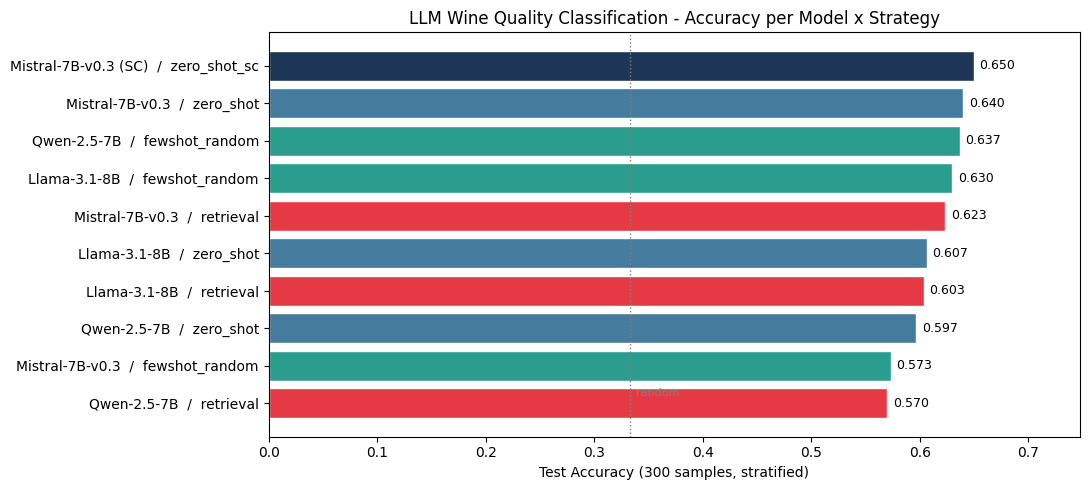

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = results_df.copy()
plot_df["combo"] = plot_df["model"] + "  /  " + plot_df["strategy"]
plot_df = plot_df.sort_values("accuracy", ascending=True)

colors = {"zero_shot": "#457b9d", "fewshot_random": "#2a9d8f",
           "retrieval": "#e63946", "zero_shot_sc": "#1d3557",
           "fewshot_random_sc": "#264653", "retrieval_sc": "#9d0208"}
bar_colors = [colors.get(s, "#888888") for s in plot_df["strategy"]]
ax.barh(plot_df["combo"], plot_df["accuracy"], color=bar_colors, edgecolor="white")
for i, v in enumerate(plot_df["accuracy"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, max(plot_df["accuracy"]) * 1.15)
ax.set_xlabel("Test Accuracy (300 samples, stratified)")
ax.set_title("LLM Wine Quality Classification - Accuracy per Model x Strategy")
ax.axvline(1 / NUM_CLASSES, color="gray", linestyle=":", linewidth=1)
ax.text(1 / NUM_CLASSES + 0.005, 0.2, "random", color="gray", fontsize=8)
plt.tight_layout()
plt.savefig("llm_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


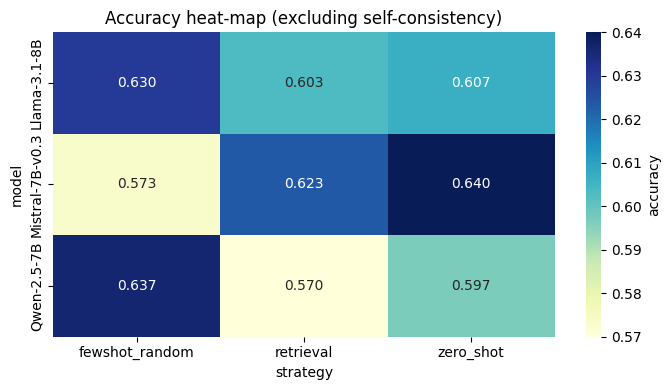

In [17]:
pivot = (results_df[~results_df["strategy"].str.endswith("_sc")]
         .pivot(index="model", columns="strategy", values="accuracy"))
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax,
             cbar_kws={"label": "accuracy"})
ax.set_title("Accuracy heat-map (excluding self-consistency)")
plt.tight_layout()
plt.savefig("llm_accuracy_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Confusion Matrices

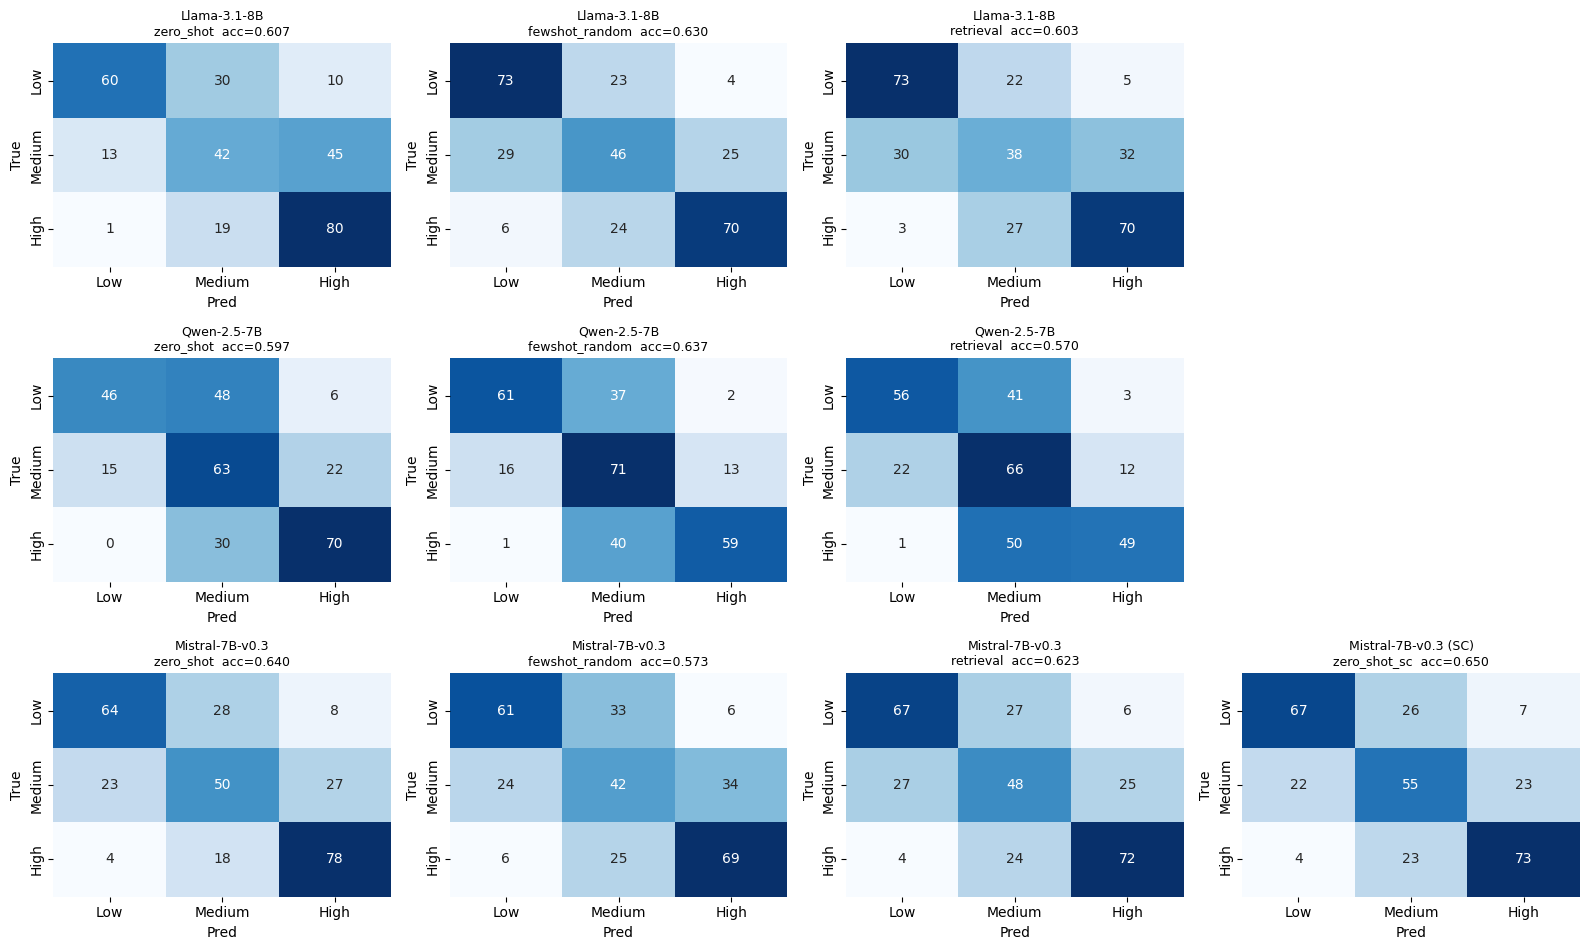

In [18]:
fig, axes = plt.subplots(len(LLM_MODELS), len(STRATEGIES) + (1 if any(r['strategy'].endswith('_sc') for r in all_runs) else 0),
                          figsize=(4 * (len(STRATEGIES) + 1), 3.2 * len(LLM_MODELS)))

if axes.ndim == 1:
    axes = axes.reshape(1, -1)

strategies_full = STRATEGIES + ([best_run["strategy"] + "_sc"] if all_runs[-1]["strategy"].endswith("_sc") else [])
strategy_to_col = {s: i for i, s in enumerate(strategies_full)}
model_to_row    = {name: i for i, (_, name) in enumerate(LLM_MODELS)}
model_to_row[best_run["model"] + " (SC)"] = model_to_row[best_run["model"]]

for ax in axes.flat:
    ax.axis("off")

for run in all_runs:
    base_model_name = run["model"].replace(" (SC)", "")
    if base_model_name not in model_to_row or run["strategy"] not in strategy_to_col:
        continue
    if "(SC)" in run["model"]:
        col = strategy_to_col.get(run["strategy"], len(STRATEGIES))
    else:
        col = strategy_to_col[run["strategy"]]
    row = model_to_row[base_model_name]
    ax = axes[row, col]
    ax.axis("on")
    cm = confusion_matrix(run["labels"], run["preds"], labels=list(range(NUM_CLASSES)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                 xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    acc = accuracy_score(run["labels"], run["preds"])
    ax.set_title(f"{run['model']}\n{run['strategy']}  acc={acc:.3f}", fontsize=9)
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("llm_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Save Results

In [19]:
results_df.round(4).to_csv("llm_results.csv", index=False)
print("Saved: llm_results.csv")
print("Saved: llm_accuracy_comparison.png")
print("Saved: llm_accuracy_heatmap.png")
print("Saved: llm_confusion_matrices.png")

import pickle
serialisable = []
for r in all_runs:
    serialisable.append({
        "model":          r["model"],
        "strategy":       r["strategy"],
        "preds":          r["preds"].tolist(),
        "labels":         r["labels"].tolist(),
        "raw":            r["raw"][:50] if isinstance(r["raw"], list) else None,
        "parse_failures": r["parse_failures"],
        "elapsed_s":      r["elapsed_s"],
    })
with open("llm_runs.pkl", "wb") as f:
    pickle.dump(serialisable, f)
print("Saved: llm_runs.pkl  (runs metadata + first 50 raw outputs per run)\n")

latex_cols = ["model", "strategy", "accuracy", "f1_weighted", "cohen_kappa",
               "mcc", "mae_ordinal", "rank_acc_pm1", "spearman_rho"]
print(results_df[latex_cols].round(4).to_latex(index=False, escape=True))


Saved: llm_results.csv
Saved: llm_accuracy_comparison.png
Saved: llm_accuracy_heatmap.png
Saved: llm_confusion_matrices.png
Saved: llm_runs.pkl  (runs metadata + first 50 raw outputs per run)

\begin{tabular}{llrrrrrrr}
\toprule
model & strategy & accuracy & f1\_weighted & cohen\_kappa & mcc & mae\_ordinal & rank\_acc\_pm1 & spearman\_rho \\
\midrule
Mistral-7B-v0.3 (SC) & zero\_shot\_sc & 0.650000 & 0.650900 & 0.475000 & 0.475300 & 0.386700 & 0.963300 & 0.652100 \\
Mistral-7B-v0.3 & zero\_shot & 0.640000 & 0.637600 & 0.460000 & 0.461000 & 0.400000 & 0.960000 & 0.647300 \\
Qwen-2.5-7B & fewshot\_random & 0.636700 & 0.645400 & 0.455000 & 0.468700 & 0.373300 & 0.990000 & 0.671200 \\
Llama-3.1-8B & fewshot\_random & 0.630000 & 0.627400 & 0.445000 & 0.445400 & 0.403300 & 0.966700 & 0.653900 \\
Mistral-7B-v0.3 & retrieval & 0.623300 & 0.622800 & 0.435000 & 0.435100 & 0.410000 & 0.966700 & 0.643600 \\
Llama-3.1-8B & zero\_shot & 0.606700 & 0.603400 & 0.410000 & 0.416900 & 0.430000 & 0.963300